# MR4010 Navegación Autónoma

## Redes Neuronales con Keras

# Clasificación Binaria usando Keras

En este notebook se implementa una red neuronal artificial (ANN)
utilizando Keras para resolver un problema de clasificación binaria.

Se utilizará el dataset sintético `make_moons` de Scikit-Learn,
el cual contiene dos clases no linealmente separables.

Objetivos:
- Crear un perceptrón simple
- Evaluar desempeño
- Visualizar exactitud y pérdida
- Visualizar la frontera de decisión
- Mejorar el modelo agregando capas ocultas

Lee el capítulo 4 del libro de texto:

Venturi, L. y Korda, K. (2020). Hands-On Vision and Behavior For Self-Driving Cars. Packt Publishing. Disponible en: https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtmlLinks to an external site.


Lee el capítulo 2 del libro de texto:

Ranjan, S. y Senthamilarasu S.(2020). Applied Deep Learning and Computer Vision
for Self-Driving Cars. Packt Publishing Ltd.
Links to an external site.https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/?sso_link=yes&sso_link_from=ITESLinks to an external site.



## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

![image.png](attachment:image.png)

In [61]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# Paso 2 — Cargar bibliotecas

Explicación rápida:

numpy: nos ayuda con matrices, vectores y operaciones matemáticas.

matplotlib: nos ayuda a graficar los datos y la frontera de decisión.

%matplotlib inline: permite que las gráficas aparezcan dentro del notebook.

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

from matplotlib.colors import ListedColormap

import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

print(r'Tensor flow: ',tf.__version__)

Tensor flow:  2.21.0


## Paso 3 - Cargar dataset

### Se carga como DataFrame un dataset de prueba

### Dataset make_moons

Se carga el dataset sintético `make_moons`
con 2000 muestras y un pequeño nivel de ruido.

Este dataset es ideal para demostrar cómo
una red neuronal puede aprender fronteras
de decisión no lineales.

In [63]:
# Se genera el dataset

noisy_moons = datasets.make_moons(
    n_samples=2000,
    noise=0.05,
    random_state=42
)

# Se separan features y etiquetas
X, y = noisy_moons

# Dimensiones
print(X.shape)
print(y.shape)

(2000, 2)
(2000,)


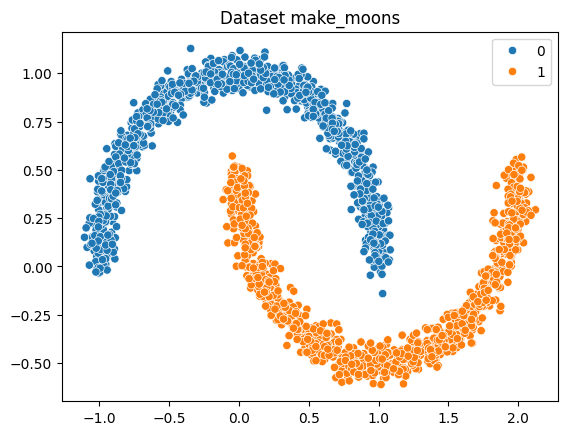

In [64]:
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=y
)

plt.title("Dataset make_moons")
plt.show()

### Exploración del dataset

Se revisa:

- Número de registros
- Tipos de datos
- Valores nulos

### Conversión a DataFrame

Se crea un DataFrame para visualizar
los datos de manera estructurada.

In [65]:
# ------------------------------------------------------------
# Información general del dataset
# ------------------------------------------------------------

df_noisy_moons = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

df_noisy_moons['target'] = y

df_noisy_moons.head()

,Feature_1,Feature_2,target
0,1.841241,0.134711,1
1,0.421194,0.913065,0
2,0.497654,-0.342173,1
3,-0.952785,0.227169,0
4,0.435144,-0.313472,1


## Paso 5 - Visualizacion del sataset

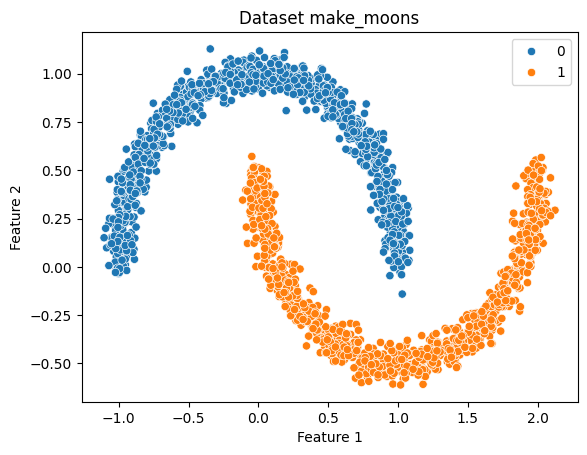

In [66]:
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    hue=y
)

plt.title("Dataset make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Step 6 - Division de entrenamiento y prueba

# División Train/Test

Se divide el dataset en:
- 75% entrenamiento
- 25% prueba

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1500, 2)
(500, 2)


## Paso 6 - Escalamiento de Datos

### Escalamiento MinMax

Los datos se escalan entre 0 y 1
para mejorar el entrenamiento de la red neuronal.### Creación de variables de entrada y salida

X_train contiene las variables independientes.

y_train contiene las etiquetas o clases.

In [68]:
# Escalador
scaler = MinMaxScaler()

# Ajuste y transformación entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformación prueba
X_test_scaled = scaler.transform(X_test)

### Paso 7 - Visualizacion de datos escalados

### Datos Escalados

Se visualizan los datos ya normalizados.### Construcción de la red neuronal

Se utiliza una sola neurona ya que:

- El problema es de clasificación binaria
- Esto equivale matemáticamente a una regresión logística

Características del modelo:

- 2 entradas
- 1 salida
- Función de activación Sigmoid
- Optimizador Adam
- Función de pérdida Binary Crossentropy

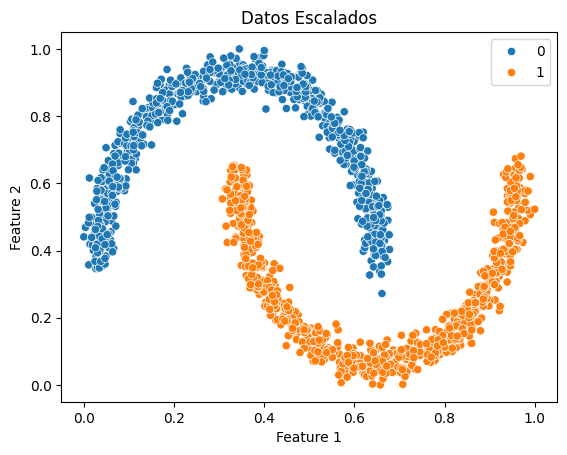

In [69]:
sns.scatterplot(
    x=X_train_scaled[:,0],
    y=X_train_scaled[:,1],
    hue=y_train
)

plt.title("Datos Escalados")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Paso 8 - Modelo 1 perceptron simple

### Modelo 1: Perceptrón Simple

Se crea una red neuronal con:
- 2 entradas
- 1 neurona de salida
- Activación Sigmoid

Este modelo representa un perceptrón simple.### Entrenamiento del modelo

Parámetros utilizados:

- epochs = 100
- batch_size = 50
- shuffle = True

El modelo aprenderá los pesos óptimos
para clasificar correctamente los datos.

In [70]:
model = Sequential()

model.add(
    Dense(
        units=1,
        input_dim=2,
        activation='sigmoid'
    )
)

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 10 - Entrenamienro del modelo

### Entrenamiento

Se entrena el modelo durante 100 épocas.### Resumen de la arquitectura

Se muestran:

- Número de capas
- Número de parámetros
- Dimensiones de entrada y salida

In [71]:
hist = model.fit(
    x=X_train_scaled,
    y=y_train,
    verbose=1,
    batch_size=50,
    epochs=100,
    shuffle=True
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.5060 - loss: 0.6714
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.6660 - loss: 0.5992
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - accuracy: 0.8147 - loss: 0.5491
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.8520 - loss: 0.5098
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.8640 - loss: 0.4775
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - accuracy: 0.8713 - loss: 0.4504
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.8767 - loss: 0.4275
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - accuracy: 0.8807 - loss: 0.4080
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.8807 - loss: 0.3910
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.8820 - loss: 0.3764
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step - accuracy: 0.8820 - loss: 0.3636
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0

## Paso 11 - resumen del modelo

### Arquitectura del Modelo

In [72]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

## Paso 12 - Graficar exactitud

### Evolución de la exactitud

Se observa cómo mejora el accuracy
durante el entrenamiento.

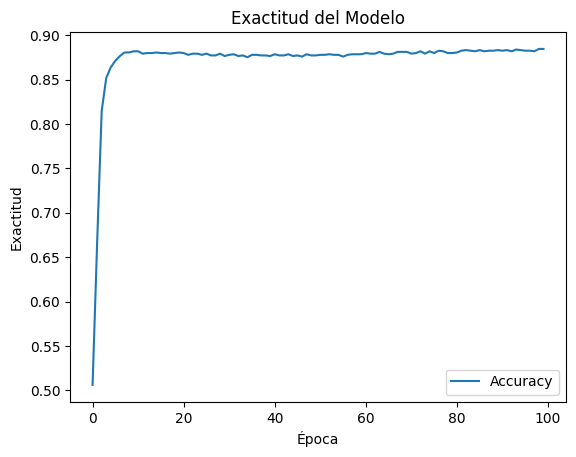

In [73]:
# ------------------------------------------------------------
# Graficar accuracy
# ------------------------------------------------------------

plt.plot(hist.history['accuracy'])

plt.title("Exactitud del Modelo")
plt.ylabel("Exactitud")
plt.xlabel("Época")

plt.legend(['Accuracy'])

plt.show()

## Paso 13 - Graficar error

### Evolución del error

Se visualiza cómo disminuye la función de pérdida.

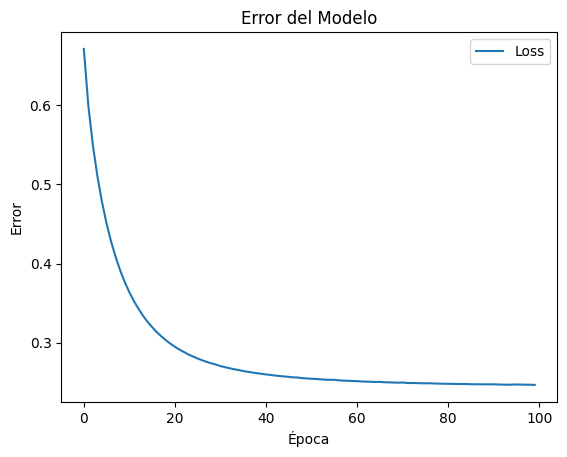

In [74]:
# ------------------------------------------------------------
# Graficar pérdida (loss)
# ------------------------------------------------------------

plt.plot(hist.history['loss'])

plt.title("Error del Modelo")
plt.ylabel("Error")
plt.xlabel("Época")

plt.legend(['Loss'])

plt.show()

## Paso 14 - Visualizar frontera de decision

### Visualización de resultados

### Frontera de Clasificación

Se visualiza la frontera de decisión aprendida
por la red neuronal.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step


C:\Users\baraj\AppData\Local\Temp\ipykernel_61824\1535418120.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


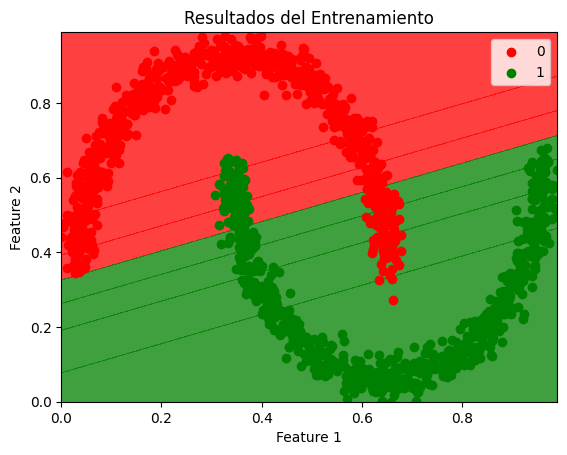

In [75]:
X_grid, y_grid = X_train_scaled, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=X_grid[:,0].min(),
        stop=X_grid[:,0].max(),
        step=0.01
    ),

    np.arange(
        start=X_grid[:,1].min(),
        stop=X_grid[:,1].max(),
        step=0.01
    )
)

predictions = model.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)

predictions = predictions.reshape(X1.shape)

plt.contourf(
    X1,
    X2,
    predictions,
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_grid)):

    plt.scatter(
        X_grid[y_grid == j, 0],
        X_grid[y_grid == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Resultados del Entrenamiento')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()

plt.show()

## Paso 15 - Mostrar pesos del modelo

### Pesos aprendidos por la neurona

La red neuronal aprende:

- Pesos (weights)
- Biases

In [76]:
# ------------------------------------------------------------
# Obtener pesos y bias
# ------------------------------------------------------------

weights, biases = model.layers[0].get_weights()

# ------------------------------------------------------------
# Mostrar pesos
# ------------------------------------------------------------

print("Pesos aprendidos:")
print(weights)

# ------------------------------------------------------------
# Mostrar bias
# ------------------------------------------------------------

print("\nBias aprendido:")
print(biases)

Pesos aprendidos:
[[ 3.772105]
 [-9.646329]]

Bias aprendido:
[2.9441087]


## Paso 16 - Predicciones

### Prueba con un dato arbitrario

Se evalúa una nueva entrada:

- Distancia = 0.1
- Altura = 0.2

El modelo devuelve una probabilidad.

In [77]:
y_predict = (
    model.predict(X_test_scaled) > 0.5
).astype("int32")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step


## Paso 17 - Matriz de confusion

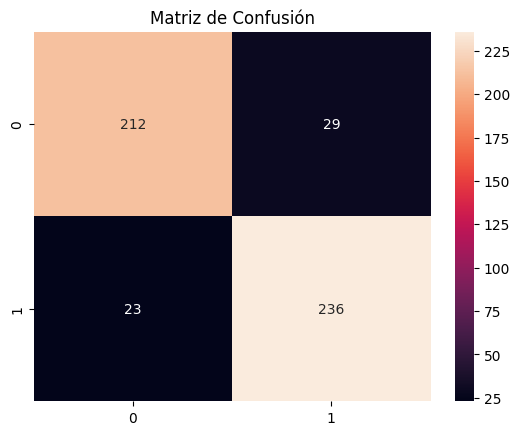

In [78]:
cm = confusion_matrix(y_test, y_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión")

plt.show()

## Paso 18 - Reporte de clasificacion

In [79]:
print(
    classification_report(
        y_test,
        y_predict
    )
)

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       241
           1       0.89      0.91      0.90       259

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



## Paso 19 - Modelo Mejorado - Red Neuronal Profunda

In [80]:
model = Sequential()

# Primera capa oculta
model.add(
    Dense(
        units=20,
        input_dim=2,
        activation='relu'
    )
)

# Segunda capa oculta
model.add(
    Dense(
        units=20,
        activation='relu'
    )
)

# Tercera capa oculta
model.add(
    Dense(
        units=20,
        activation='relu'
    )
)

# Capa de salida
model.add(
    Dense(
        units=1,
        activation='sigmoid'
    )
)

# Compilación
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 20 - Entrenamiento del modelo profundo

In [81]:
hist = model.fit(
    x=X_train_scaled,
    y=y_train,
    verbose=1,
    batch_size=50,
    epochs=100,
    shuffle=True
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8527 - loss: 0.4004   
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.8707 - loss: 0.2840
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.8820 - loss: 0.2617
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8760 - loss: 0.2579
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8767 - loss: 0.2604
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.8827 - loss: 0.2464
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - accuracy: 0.8827 - loss: 0.2408
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.8933 - loss: 0.2352
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.8933 - loss: 0.2251
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.8887 - loss: 0.2223
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.8967 - loss: 0.2221
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 

## Paso 21 - Perdida del modelo profundo

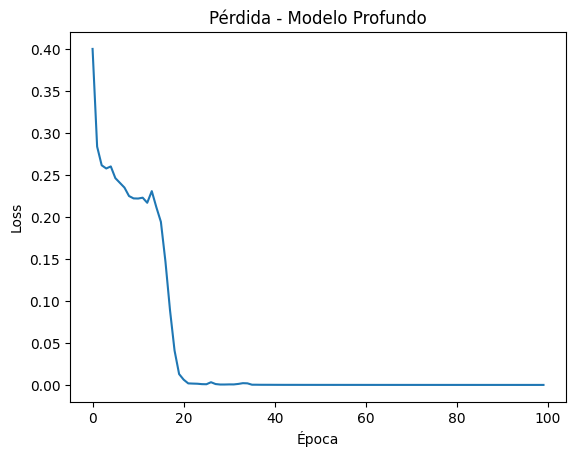

In [82]:
plt.plot(hist.history['loss'])

plt.title("Pérdida - Modelo Profundo")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.show()

## Paso 22 - Frontera de decision mejorada

### Frontera de Decisión Mejorada

Ahora la red neuronal puede aprender
la forma curva del dataset.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step


C:\Users\baraj\AppData\Local\Temp\ipykernel_61824\1983597610.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


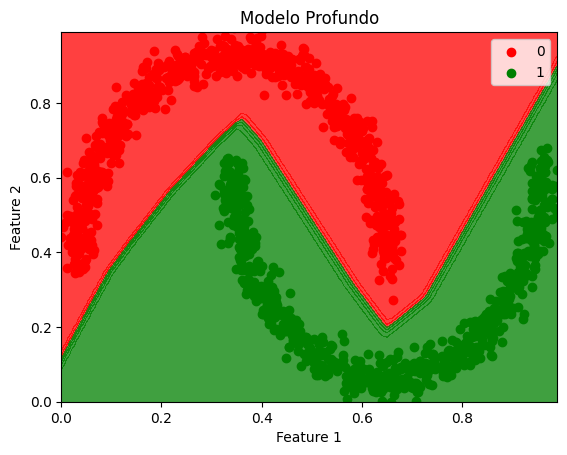

In [83]:
X_grid, y_grid = X_train_scaled, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=X_grid[:,0].min(),
        stop=X_grid[:,0].max(),
        step=0.01
    ),

    np.arange(
        start=X_grid[:,1].min(),
        stop=X_grid[:,1].max(),
        step=0.01
    )
)

predictions = model.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)

predictions = predictions.reshape(X1.shape)

plt.contourf(
    X1,
    X2,
    predictions,
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_grid)):

    plt.scatter(
        X_grid[y_grid == j, 0],
        X_grid[y_grid == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Modelo Profundo')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()

plt.show()

## Paso 23 - Evaluacion Final 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step


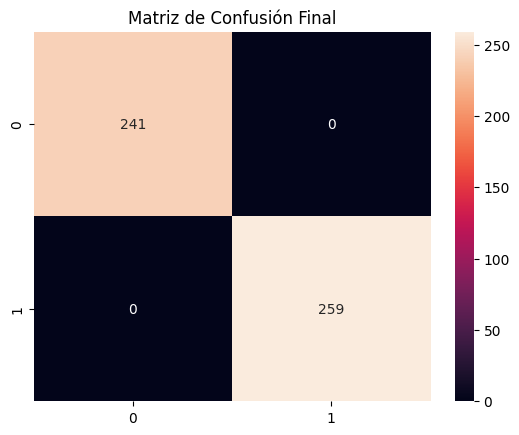

In [84]:
y_predict = (
    model.predict(X_test_scaled) > 0.5
).astype("int32")

cm = confusion_matrix(y_test, y_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión Final")

plt.show()

## Paso 24 - Reporte final

# Conclusiones

- El perceptrón simple solamente puede aprender
  fronteras lineales.

- El dataset make_moons requiere una frontera
  no lineal para separar correctamente las clases.

- Las capas ocultas y las funciones de activación ReLU
  permiten aprender patrones complejos.

- La red neuronal profunda obtiene mejor exactitud
  y una mejor frontera de clasificación.

- Keras facilita enormemente la construcción
  y entrenamiento de redes neuronales.